Import and Load

In [83]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from tqdm.notebook import tqdm
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score as ras

In [84]:
df = pd.read_csv("C:\\Users\\Sepehr\\Downloads\\parkinson_disease.csv")
pd.set_option('display.max_columns', 10)
df.sample(5)

,id,gender,PPE,DFA,RPDE,...,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
508,169,1,0.74581,0.67631,0.60931,...,30.2127,50.1590,57.5443,156.4237,1
408,136,0,0.76874,0.78653,0.37494,...,6.7870,4.2669,3.2491,3.1642,0
4,1,0,0.32790,0.79782,0.53028,...,11.6891,8.2103,5.0559,6.1164,1
183,61,1,0.82330,0.69145,0.52755,...,38.6464,38.6023,42.0771,92.6621,1
593,197,0,0.83045,0.71832,0.26936,...,3.1681,3.9787,4.8948,3.5699,1


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


In [86]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,756.0,125.500000,72.793721,0.000000,62.750000,125.500000,188.250000,251.00000
gender,756.0,0.515873,0.500079,0.000000,0.000000,1.000000,1.000000,1.00000
PPE,756.0,0.746284,0.169294,0.041551,0.762833,0.809655,0.834315,0.90766
DFA,756.0,0.700414,0.069718,0.543500,0.647053,0.700525,0.754985,0.85264
RPDE,756.0,0.489058,0.137442,0.154300,0.386537,0.484355,0.586515,0.87123
...,...,...,...,...,...,...,...,...
tqwt_kurtosisValue_dec_33,756.0,12.375335,16.341665,1.628700,3.114375,4.741450,12.201325,73.53220
tqwt_kurtosisValue_dec_34,756.0,14.799230,15.722502,1.861700,3.665925,6.725700,21.922050,62.00730
tqwt_kurtosisValue_dec_35,756.0,14.751559,14.432979,1.955900,3.741275,7.334250,22.495175,57.54430
tqwt_kurtosisValue_dec_36,756.0,31.481110,34.230991,2.364000,3.948750,10.637250,61.125325,156.42370


In [87]:

df.isnull().sum().sum()

np.int64(0)

In [88]:
df = df.groupby('id').mean().reset_index()
df.drop('id', axis=1, inplace=True)

In [89]:
df.head()

,gender,PPE,DFA,RPDE,numPulses,...,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,1.0,0.823387,0.696370,0.567250,235.333333,...,6.259100,4.021533,4.164333,22.961700,1.0
1,0.0,0.415637,0.793993,0.592453,213.333333,...,7.933133,5.490533,4.941833,4.467233,1.0
2,1.0,0.801973,0.619967,0.520563,319.333333,...,4.772067,9.176633,11.848100,5.552367,1.0
3,0.0,0.828707,0.626097,0.537183,493.000000,...,3.085267,3.184433,4.032933,22.773633,1.0
4,0.0,0.831287,0.779397,0.726717,362.666667,...,2.811367,7.268333,13.338833,63.766900,1.0


In [90]:
len(df.columns)

754

In [91]:
columns = list(df.columns)
for col in columns:
    if col == 'class':
        continue

    filtered_columns = [col]
    for col1 in df.columns:
        if((col == col1) | (col == 'class')):
            continue

        val = df[col].corr(df[col1])
        if val > 0.7:
            # If the correlation between the two features is more than 0.7, remove it
            columns.remove(col1)
            continue
        else:
            filtered_columns.append(col1)
            
    df = df[filtered_columns]
df.shape

(252, 287)

In [92]:
X = df.drop('class', axis=1)
X_norm = MinMaxScaler().fit_transform(X)
selector = SelectKBest(chi2, k=30)
selector.fit(X_norm, df['class'])
filtered_columns = selector.get_support()
filtered_data = X.loc[:, filtered_columns].copy()
filtered_data['class'] = df['class']
df = filtered_data
df.shape

(252, 31)

In [93]:
len(df.columns)

31

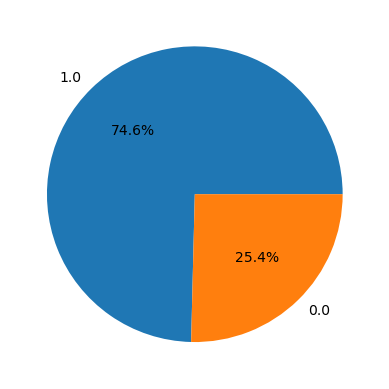

In [94]:
x = df['class'].value_counts()
plt.pie(x.values,
        labels = x.index,
        autopct='%1.1f%%')
plt.show()

In [95]:
features = df.drop('class', axis=1)
target = df['class']

X_train, X_val, Y_train, y_val = train_test_split(
    features, target, test_size=0.2, random_state=10
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
ros = RandomOverSampler(sampling_strategy=1.0, random_state=0)
X_resampled, Y_resampled = ros.fit_resample(X_train, Y_train)

X_resampled.shape, Y_resampled.value_counts()

((302, 30),
 class
 1.0    151
 0.0    151
 Name: count, dtype: int64)

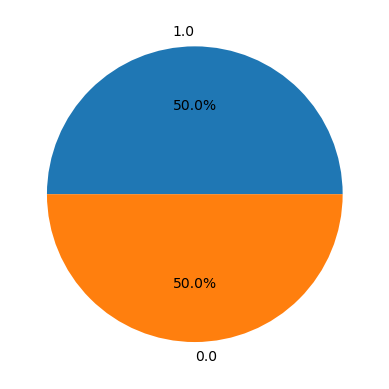

In [96]:
x = Y_resampled.value_counts()
plt.pie(x.values,
        labels = x.index,
        autopct='%1.1f%%')
plt.show()

In [97]:
pd.DataFrame(X_resampled)

,0,1,2,3,4,...,25,26,27,28,29
0,0.035120,0.020287,0.018549,0.030237,0.176821,...,0.033804,0.660692,0.293598,0.599002,0.0
1,0.023548,0.001035,0.000349,0.000716,0.246072,...,0.003838,0.011006,0.536430,0.317944,1.0
2,0.382960,0.001545,0.002424,0.004346,0.190556,...,0.211350,0.008534,0.231500,0.701854,1.0
3,0.058071,0.439880,0.612584,0.451938,0.457574,...,0.011782,0.219708,0.601385,0.299410,0.0
4,0.716405,0.009659,0.007210,0.003031,0.426157,...,0.122522,0.042274,0.318716,0.524214,1.0
...,...,...,...,...,...,...,...,...,...,...,...
297,0.032667,0.023511,0.000504,0.000491,0.395778,...,0.048183,0.039205,0.472839,0.532425,1.0
298,0.382574,0.147102,0.101819,0.070811,0.294398,...,0.000000,0.541328,0.835256,0.096133,0.0
299,0.037388,0.163592,0.455144,0.001141,0.463572,...,0.090397,0.072472,0.674127,0.737972,0.0
300,0.071912,0.303663,0.308277,0.001057,0.588263,...,0.012538,0.049412,0.558731,0.497696,0.0


In [98]:

models = [LogisticRegression(class_weight='balanced',max_iter=1000, solver="lbfgs", C=1.2), XGBClassifier(), SVC(kernel='rbf', probability=True,max_iter=1000,class_weight='balanced' )] 
for model in models:
    model.fit(X_resampled, Y_resampled)
    print(f'{model} : ')

    train_preds = model.predict(X_resampled)
    print('Training Accuracy : ', ras(Y_resampled, train_preds))

    val_preds = model.predict(X_val)
    print('Validation Accuracy : ', ras(y_val, val_preds))
    print()

LogisticRegression(C=1.2, class_weight='balanced', max_iter=1000) : 
Training Accuracy :  0.8211920529801325
Validation Accuracy :  0.7268339768339769

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  1.0
Validation Accuracy :  0.6467181467181468

SVC(class_weight

In [99]:
from sklearn.metrics import classification_report

print(classification_report(y_val, models[0].predict(X_val)))

              precision    recall  f1-score   support

         0.0       0.56      0.64      0.60        14
         1.0       0.86      0.81      0.83        37

    accuracy                           0.76        51
   macro avg       0.71      0.73      0.72        51
weighted avg       0.78      0.76      0.77        51



<function matplotlib.pyplot.show(close=None, block=None)>

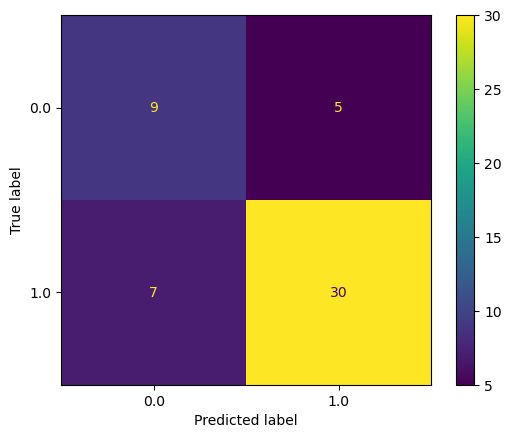

In [100]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_estimator(models[0], X_val, y_val)
plt.show